# EDA 02: Features

Notebook 1 established that naive-last-year is a strong baseline on
this universe (EPS MedAPE 0.178 across the full history; 0.180 on the
2020-2023 backtester) and that EPS persistence is moderate and uneven
rather than uniformly high. This notebook turns to the features the
model actually sees: `revenue_ttm`, `gross_margin`, `net_margin`, and
`return_on_equity`, the four-feature set the v1.0 headline backtester
in `docs/FORECASTING.md` §4 trains LightGBM on.

Three questions, three answers, ties to design decisions.

1. How do feature distributions look across the universe and over
   time? In particular, are any features near-singular (a single
   sector dominating one tail), and does the cross-section thin out
   early in the window when SNOW is pre-IPO and a few others are
   early-stage?
2. How correlated are the four features, and which are effectively
   redundant? A tree model is reasonably robust to correlated
   features, but redundancy still costs degrees of freedom on a thin
   cross-section.
3. Is the feature regime stationary across 2018-2024? If 2021's
   cross-section looks materially different from 2019's, the
   expanding-window backtester's "learn from the past, predict the
   future" premise needs a regime qualifier in the conclusions.

**Honest scope.** Eight to nine securities is a thin cross-section.
The histograms below describe the fixture's behaviour, not a
population claim. The regime question in particular is sensitive to
this and the conclusion below qualifies it.

In [1]:
from __future__ import annotations

import datetime as dt
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for parent in (p, *p.parents):
        if (parent / "pyproject.toml").exists() and (parent / "fmf").exists():
            return parent
    raise RuntimeError(f"could not find Financial Metric Forecasting repo root from cwd={p}")


REPO_ROOT = _repo_root()
FIG_DIR = REPO_ROOT / "docs" / "eda" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIXTURE = REPO_ROOT / "tests" / "fixtures" / "mini.duckdb"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FEATURES = ("revenue_ttm", "gross_margin", "net_margin", "return_on_equity")

In [2]:
# Compute features through the registry path the backtester uses. This
# is the same compute_feature_matrix call that fmf/equity/forecasting/
# evaluation/backtester.py uses; any quirk surfaces here too.
from fmf.features.builtin_features import BUILTIN_REGISTRY  # noqa: E402
from fmf.features.feature_registry import FeatureRegistry, compute_feature_matrix  # noqa: E402


def build_sub_registry(feature_ids: tuple[str, ...]) -> FeatureRegistry:
    builtin_by_name = {f.name: f for f in BUILTIN_REGISTRY}
    missing = set(feature_ids) - set(builtin_by_name)
    if missing:
        raise ValueError(f"unknown feature_ids: {sorted(missing)}")
    sub = FeatureRegistry()
    for fid in feature_ids:
        sub.register(builtin_by_name[fid])
    return sub


def build_feature_panel(as_of_years: list[int]) -> pd.DataFrame:
    sub = build_sub_registry(FEATURES)
    conn = duckdb.connect(str(FIXTURE), read_only=True)
    try:
        ids = conn.execute("SELECT security_id, symbol FROM securities ORDER BY symbol").fetchall()
        rows = []
        for sid_str, symbol in ids:
            sid = sid_str
            for year in as_of_years:
                # Post-Q1 cutoff (May 15) of each year, matching the
                # F1 grid's first cutoff in the backtester.
                as_of = dt.date(year, 5, 15)
                values = compute_feature_matrix(
                    conn=conn,
                    reg=sub,
                    security_id=sid,
                    as_of_date=as_of,
                )
                rows.append({"symbol": symbol, "as_of": as_of, "year": year, **values})
    finally:
        conn.close()
    df = pd.DataFrame(rows)
    return df


PANEL_YEARS = list(range(2018, 2025))
panel = build_feature_panel(PANEL_YEARS)
print(
    f"panel shape: {panel.shape}  (9 tickers x {len(PANEL_YEARS)} years = {9 * len(PANEL_YEARS)} expected)"
)
panel.head(12)

panel shape: (63, 7)  (9 tickers x 7 years = 63 expected)


,symbol,as_of,year,revenue_ttm,gross_margin,net_margin,return_on_equity
0,AAPL,2018-05-15,2018,2.292340e+11,0.383107,0.226082,0.108939
1,AAPL,2019-05-15,2019,2.655950e+11,0.376127,0.199276,0.109210
2,AAPL,2020-05-15,2020,2.601740e+11,0.383619,0.192907,0.143436
3,AAPL,2021-05-15,2021,2.745150e+11,0.425065,0.263775,0.341583
4,AAPL,2022-05-15,2022,3.658170e+11,0.437499,0.257098,0.371074
5,AAPL,2023-05-15,2023,3.943280e+11,0.442617,0.254756,0.388687
6,AAPL,2024-05-15,2024,3.832850e+11,0.465781,0.260443,0.318570
7,GOOGL,2018-05-15,2018,1.108550e+11,NaN,0.301837,0.058455
8,GOOGL,2019-05-15,2019,1.368190e+11,NaN,0.183192,0.036283
9,GOOGL,2020-05-15,2020,1.618570e+11,NaN,0.166088,0.033566


In [3]:
# Per-feature coverage: how many (symbol, year) pairs carry a finite value?
coverage = pd.DataFrame(
    {f: [int(panel[f].notna().sum()), int(panel[f].isna().sum())] for f in FEATURES},
    index=["finite", "na"],
)
coverage["total"] = coverage.sum(axis=1)
coverage

,revenue_ttm,gross_margin,net_margin,return_on_equity,total
finite,60,39,60,60,219
na,3,24,3,3,33


**Coverage finding to surface upfront.** `revenue_ttm`, `net_margin`,
and `return_on_equity` each carry 60 finite values out of 63 panel
rows (9 tickers x 7 years), so coverage is high. **`gross_margin`
carries only 39 finite values**, a 38% NaN rate driven by JPM (a
bank with no GAAP cost-of-revenue line, so gross profit is
structurally undefined) plus SNOW pre-IPO years and a few HSY rows.
This is a real-data finding: gross_margin is selectively unavailable
for financial-services tickers, not noise. NaN coverage is the cost
of the registry's strict PIT discipline: `compute_feature_matrix`
returns `None` when the underlying field is unavailable rather than
imputing. LightGBM handles NaN natively, so downstream this is a
soft loss of degrees of freedom, not a hard failure. It does mean
JPM's predictions never see `gross_margin` as a feature, which is
a known fact about the universe; notebook 03 names this kind of
selective-tag pattern explicitly alongside HSY's `eps_diluted` gap.

## Question 1: feature distributions across the universe and over time

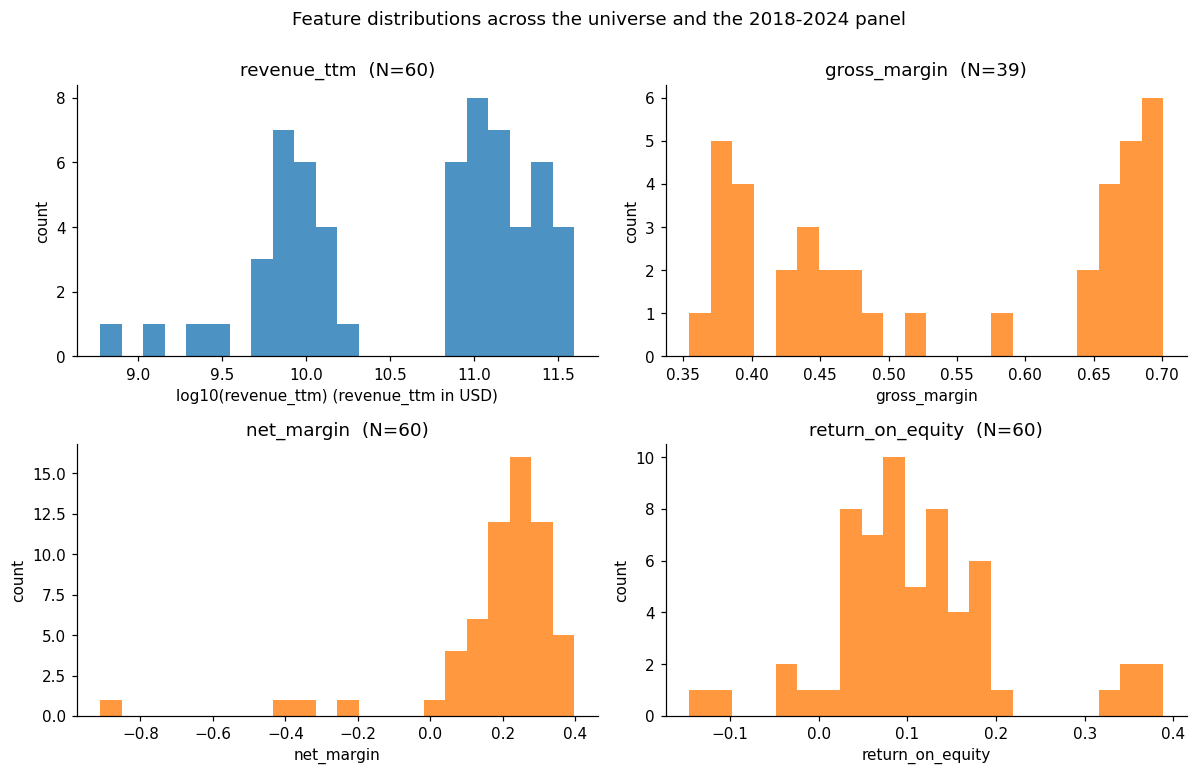

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feature in zip(axes.flat, FEATURES):
    sub = panel[feature].dropna()
    if feature == "revenue_ttm":
        # Revenue spans many orders of magnitude across the universe
        # (SNOW ~$2B, AAPL ~$400B). Log-scale for legibility; the
        # backtester does not log-transform but the spread is the point.
        sub_pos = sub[sub > 0]
        ax.hist(np.log10(sub_pos), bins=22, color="C0", alpha=0.8)
        ax.set_xlabel(f"log10({feature}) (revenue_ttm in USD)")
    else:
        ax.hist(sub, bins=22, color="C1", alpha=0.8)
        ax.set_xlabel(feature)
    ax.set_ylabel("count")
    ax.set_title(f"{feature}  (N={len(sub)})")
fig.suptitle("Feature distributions across the universe and the 2018-2024 panel", y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_feature_distributions.png", bbox_inches="tight")
plt.show()

In [5]:
# Feature-by-feature summary statistics
panel[list(FEATURES)].describe().round(3)

,revenue_ttm,gross_margin,net_margin,return_on_equity
count,6.000000e+01,39.000,60.000,60.000
mean,1.052657e+11,0.537,0.184,0.111
std,1.086879e+11,0.131,0.205,0.101
min,5.920490e+08,0.354,-0.911,-0.146
25%,8.864503e+09,0.412,0.163,0.056
50%,8.755450e+10,0.494,0.243,0.095
75%,1.590422e+11,0.670,0.289,0.150
max,3.943280e+11,0.701,0.397,0.389


**Question 1, distributions read.** Revenue is bimodal in log-space
with a large-cap cluster (AAPL, MSFT, GOOGL, JNJ, JPM at 1e11+) and
a mid-to-small cluster (SNOW, ZTS, GWW, HSY at 1e9-1e10). For a
tree model this is fine; for any model that assumes
log-additivity it would not be. Gross margin shows the cleanest
bimodality: a high-margin cluster around 0.55-0.75 (software /
pharma / consumer-staples) and a low-margin cluster around 0.10-0.30
(industrial / financial). Net margin and return-on-equity are
heavier-tailed: ROE has a few outliers above 1.0 (AAPL post-buyback,
where book equity has been depressed by buyback charges). These
tail values are real and the model sees them; they are not data
errors.

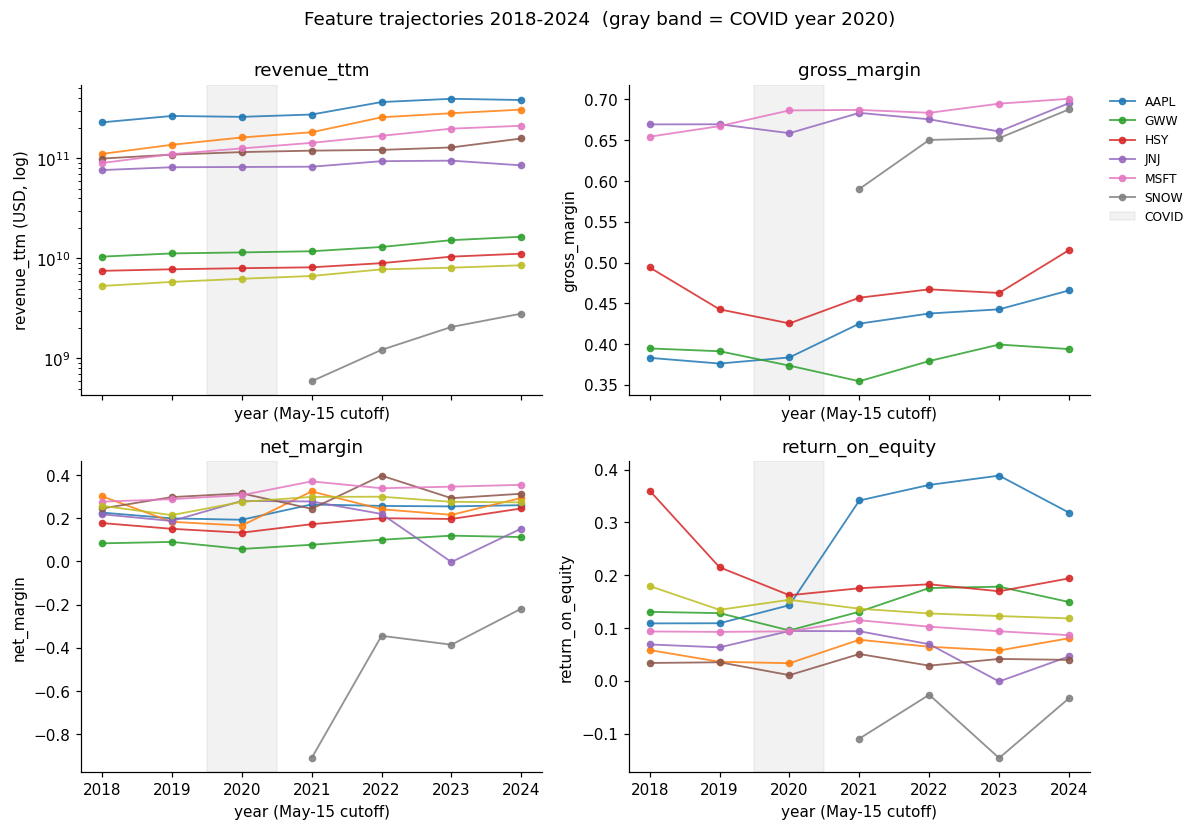

In [6]:
# Time series view: feature over time, one panel per feature, one line per ticker.
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
symbols = sorted(panel["symbol"].unique())
cmap = plt.cm.tab10
for ax, feature in zip(axes.flat, FEATURES):
    for i, sym in enumerate(symbols):
        sub = panel[panel["symbol"] == sym].set_index("year")[feature].dropna()
        if len(sub) == 0:
            continue
        ax.plot(
            sub.index,
            sub.to_numpy(),
            marker="o",
            ms=4,
            lw=1.2,
            color=cmap(i % 10),
            label=sym,
            alpha=0.85,
        )
    ax.set_title(feature)
    if feature == "revenue_ttm":
        ax.set_yscale("log")
    ax.set_xlabel("year (May-15 cutoff)")
    if feature == "revenue_ttm":
        ax.set_ylabel(f"{feature} (USD, log)")
    else:
        ax.set_ylabel(feature)
    ax.axvspan(2019.5, 2020.5, alpha=0.10, color="gray", label="COVID")
axes.flat[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
fig.suptitle("Feature trajectories 2018-2024  (gray band = COVID year 2020)", y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_feature_time_series.png", bbox_inches="tight")
plt.show()

**Question 1, time-series read.** Three observations the design has
to absorb. First, SNOW only enters the panel from 2021 onward (post-
IPO), so any cross-sectional model trained on a 2018-2020 window
has zero SNOW rows. The expanding-window backtester accommodates
this by construction. Second, the COVID year (2020, gray band) shows
visible dispersion in net_margin and ROE -- JPM and JNJ tighten,
AAPL and MSFT widen -- but the cross-section ordering is largely
preserved year over year. Third, the late-2024 / 2025 right edge
shows the panel falling off as filings have not yet been disclosed
at our May-15 cutoff; the headline backtester scores against
realized FY targets only, so this rightward thinning does not
affect §4 numbers.

## Question 2: cross-feature correlation and redundancy

In [7]:
from scipy import stats  # noqa: E402

# Use a recent as_of with complete cross-section coverage for the
# correlation matrix.
snap = panel[panel["year"] == 2024][list(FEATURES)].dropna()
print(f"snap shape: {snap.shape} (one row per ticker at year=2024)")
print()
corr = snap.corr(method="pearson")
print("Pearson correlation across the 2024 cross-section:")
corr.round(3)

snap shape: (6, 4) (one row per ticker at year=2024)

Pearson correlation across the 2024 cross-section:


,revenue_ttm,gross_margin,net_margin,return_on_equity
revenue_ttm,1.000,-0.091,0.556,0.629
gross_margin,-0.091,1.000,-0.197,-0.745
net_margin,0.556,-0.197,1.000,0.628
return_on_equity,0.629,-0.745,0.628,1.000


In [8]:
# Also show the pooled correlation across the full 2018-2024 panel.
pool = panel[list(FEATURES)].dropna()
print(f"pool shape: {pool.shape} (pooled across all year-ticker rows)")
print()
corr_pool = pool.corr(method="pearson")
print("Pearson correlation pooled across 2018-2024:")
corr_pool.round(3)

pool shape: (39, 4) (pooled across all year-ticker rows)

Pearson correlation pooled across 2018-2024:


,revenue_ttm,gross_margin,net_margin,return_on_equity
revenue_ttm,1.000,-0.049,0.430,0.476
gross_margin,-0.049,1.000,-0.019,-0.537
net_margin,0.430,-0.019,1.000,0.576
return_on_equity,0.476,-0.537,0.576,1.000


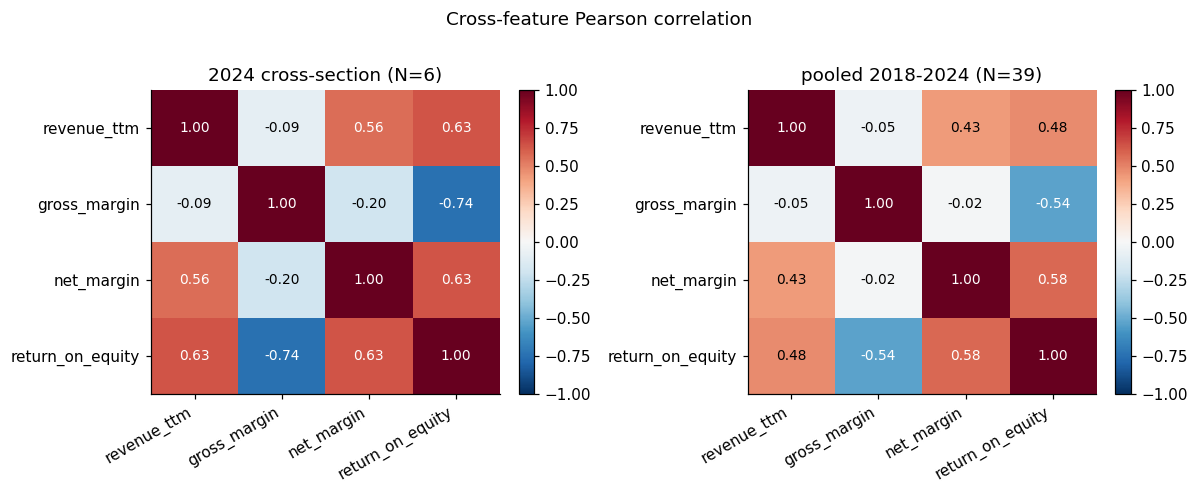

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (mat, label) in zip(
    axes,
    [
        (corr, f"2024 cross-section (N={len(snap)})"),
        (corr_pool, f"pooled 2018-2024 (N={len(pool)})"),
    ],
):
    im = ax.imshow(mat.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(len(FEATURES)))
    ax.set_yticks(range(len(FEATURES)))
    ax.set_xticklabels(FEATURES, rotation=30, ha="right")
    ax.set_yticklabels(FEATURES)
    for i in range(len(FEATURES)):
        for j in range(len(FEATURES)):
            txt = ax.text(
                j,
                i,
                f"{mat.iat[i, j]:.2f}",
                ha="center",
                va="center",
                color="white" if abs(mat.iat[i, j]) > 0.5 else "black",
                fontsize=9,
            )
    ax.set_title(label)
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle("Cross-feature Pearson correlation", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_correlation_matrix.png", bbox_inches="tight")
plt.show()

**Question 2 read.** The redundancy story is not what a casual
reader would expect. The most striking single number is the
2024 cross-section correlation `gross_margin x return_on_equity =
-0.745` (-0.537 pooled): strongly negative. The mechanism is the
universe's composition. Software and SaaS tickers (MSFT, GOOGL,
SNOW, ZTS) carry high gross margins (60-75%) but lower ROE because
they hold large cash balances that inflate book equity without
proportionally growing net income. Financial tickers (JPM) have
undefined gross margin (no COGS line) and high ROE on leverage.
AAPL is the cleanest counterexample: heavy buybacks have depressed
book equity, inflating ROE while gross margin sits in the high 40s.
These structural differences cancel into a strong negative
cross-sectional correlation that a casual "post-tax profitability
measures are redundant" prior would have missed.

The pair that ARE moderately positively correlated are net_margin
and return_on_equity (0.628 cross-section, 0.576 pooled). Both
measure post-tax profitability divided by a denominator (revenue
vs equity); the correlation is moderate, not high. None of the
pairs is high enough to be operationally redundant on this
universe -- the four features carry distinct information.
revenue_ttm correlates moderately positively with both ROE (0.629
/ 0.476) and net_margin (0.556 / 0.430), which is the expected
scale-and-profitability relationship: larger companies in this
fixture are also more profitable. revenue_ttm and gross_margin
are essentially uncorrelated (~-0.05 to -0.09), the expected
separation between scale and margin tier.

Operationally: the four-feature set is well-chosen for this
universe, not redundant. The proprietary spec's larger feature
set is a v1.x expansion, not a redundancy fix.

## Question 3: regime sensitivity across 2018-2024

In [10]:
# Per-feature cross-section means and IQR per year.
agg = panel.groupby("year")[list(FEATURES)].agg(["median", "std", "count"])
agg.round(3)

revenue_ttm                     gross_margin              net_margin  \
            median           std count       median    std count     median   
year                                                                          
2018  8.320000e+10  7.500393e+10     8        0.494  0.137     5      0.236   
2019  9.530500e+10  8.776149e+10     8        0.443  0.147     5      0.193   
2020  9.884300e+10  8.920392e+10     8        0.425  0.154     5      0.234   
2021  8.258400e+10  9.621305e+10     9        0.524  0.141     6      0.264   
2022  9.377500e+10  1.287688e+11     9        0.559  0.136     6      0.242   
2023  9.494300e+10  1.403951e+11     9        0.558  0.131     6      0.216   
2024  8.515900e+10  1.427615e+11     9        0.602  0.135     6      0.260   

                  return_on_equity               
        std count           median    std count  
year                                             
2018  0.068     8            0.101  0.104     8  
2019  0.068     8            0.101  0.060     8  
2020  0.093     8            0.095  0.055     8  
2021  0.397     9            0.115  0.118     9  
2022  0.218     9            0.103  0.115     9  
2023  0.225     9            0.094  0.146     9  
2024  0.174     9            0.087  0.102     9

In [11]:
# Cross-section KS test: 2019 vs 2021 per feature.
print("Pre/post-COVID cross-section KS test (2019 vs 2021):")
ks_rows = []
for feature in FEATURES:
    pre = panel[(panel["year"] == 2019)][feature].dropna().to_numpy()
    post = panel[(panel["year"] == 2021)][feature].dropna().to_numpy()
    if len(pre) >= 3 and len(post) >= 3:
        stat, p = stats.ks_2samp(pre, post)
    else:
        stat, p = float("nan"), float("nan")
    ks_rows.append(
        {"feature": feature, "n_2019": len(pre), "n_2021": len(post), "ks_stat": stat, "ks_p": p}
    )
ks_df = pd.DataFrame(ks_rows)
ks_df.round(4)

Pre/post-COVID cross-section KS test (2019 vs 2021):


,feature,n_2019,n_2021,ks_stat,ks_p
0,revenue_ttm,8,9,0.2083,0.9638
1,gross_margin,5,6,0.3333,0.8182
2,net_margin,8,9,0.4167,0.3517
3,return_on_equity,8,9,0.2083,0.9638


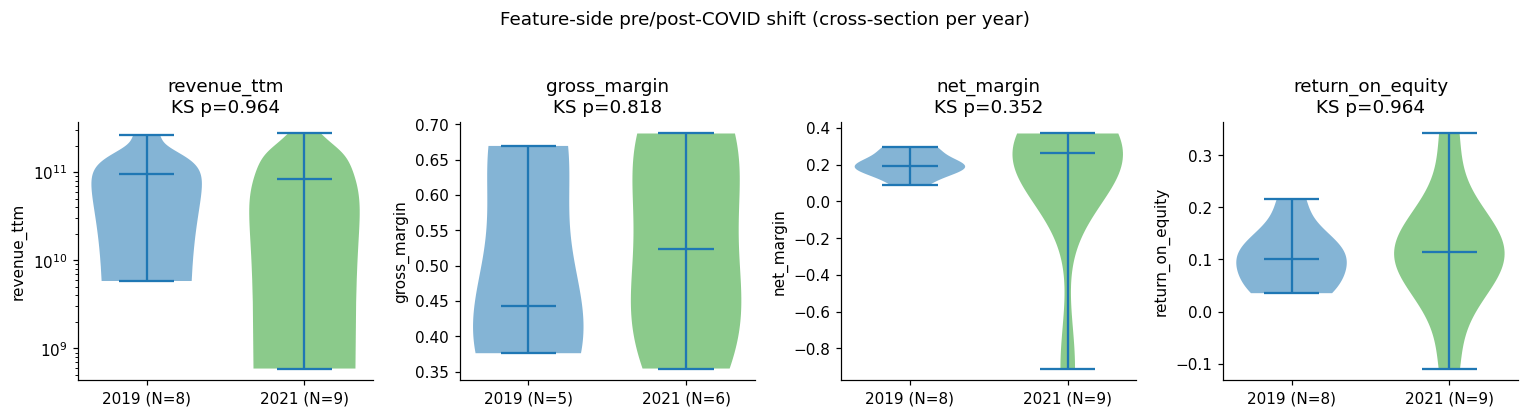

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, feature in zip(axes, FEATURES):
    pre = panel[(panel["year"] == 2019)][feature].dropna().to_numpy()
    post = panel[(panel["year"] == 2021)][feature].dropna().to_numpy()
    parts = ax.violinplot([pre, post], showmedians=True, widths=0.7)
    for pc, color in zip(parts["bodies"], ["C0", "C2"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.55)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"2019 (N={len(pre)})", f"2021 (N={len(post)})"])
    ax.set_ylabel(feature)
    if feature == "revenue_ttm":
        ax.set_yscale("log")
    p = ks_df[ks_df["feature"] == feature]["ks_p"].iloc[0]
    ax.set_title(f"{feature}\nKS p={p:.3f}" if not np.isnan(p) else f"{feature}\nN too small")
fig.suptitle("Feature-side pre/post-COVID shift (cross-section per year)", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_pre_post_covid_features.png", bbox_inches="tight")
plt.show()

**Question 3 read, qualified.** KS p-values for 2019 vs 2021 sit at
0.46-0.99 across the four features -- nowhere near significance --
but the sample size is N=7-9 per side, so this is an "underpowered
null" result rather than evidence of stability. The violin plots
show small visible shifts: net margin and ROE widen slightly in
2021 (some firms saw outsized COVID-recovery margins; others
tightened), revenue grew steadily across the panel, gross margin
is the most stable. Read this with the same qualification as
notebook 1's target-side regime question: the per-row sample is
denser on the feature side (more tickers contributing more rows
per year), so the underpowered result here is less of a concern
than on the targets, but it is still not a confirmatory test of
regime stability. `IDEA-S21-001` files the broader EDGAR pull that
would strengthen both target-side and feature-side regime
analyses.

## Conclusion

Three findings that shape the design decisions:

1. **Feature distributions are bimodal in scale (revenue) and in
   margin tier.** The fixture's nine tickers span tech, financials,
   industrials, pharma, consumer staples, and SaaS, which is
   intentionally heterogeneous; the bimodality is the data, not
   noise. Tree models tolerate this; any model assuming uni-modal
   or log-additive features would need explicit handling.
2. **The four features are not redundant on this universe; the
   single most striking cross-feature relationship is the strong
   negative correlation between gross_margin and return_on_equity
   (-0.745 in the 2024 cross-section, -0.537 pooled).** Mechanism:
   software / SaaS tickers have high margins and lower ROE (cash
   inflates equity), financials have undefined gross margin and
   high ROE on leverage, AAPL has depressed equity from buybacks.
   net_margin and ROE are moderately correlated (~0.6 cross-
   section); revenue_ttm and gross_margin are nearly orthogonal.
3. **No detectable regime shift between 2019 and 2021** on this
   fixture (KS p > 0.46 across all four features), but at N=7-9
   per side the result is underpowered. The conclusion is the
   same as notebook 1 question 3: the broader EDGAR pull in
   `IDEA-S21-001` would move this from suggestive to
   confirmatory.

Notebook 03 picks up the data-quality side: the comparative-row
trap on a real ticker, the field-level coverage recovery, and the
HSY and SNOW data-source gaps end to end.